# 1. Business Understanding



# 2. Data Preparation

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetching data from the source
real_estate_valuation = fetch_ucirepo(id=477) 
  
# data (as pandas dataframes) 
X = real_estate_valuation.data.features 
y = real_estate_valuation.data.targets 
  
# metadata 
print(real_estate_valuation.metadata) 
  
# variable information 
print(real_estate_valuation.variables) 


{'uci_id': 477, 'name': 'Real Estate Valuation', 'repository_url': 'https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set', 'data_url': 'https://archive.ics.uci.edu/static/public/477/data.csv', 'abstract': 'The real estate valuation is a regression problem. The market historical data set of real estate valuation are collected from Sindian Dist., New Taipei City, Taiwan. ', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 414, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y house price of unit area'], 'index_col': ['No'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C5J30W', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 373, 'type': 'NATIVE', 'title': 'Building real estate valuation models with comparative approach through case-based reasoning', 'authors': 'I. Yeh

In [2]:
X

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245
...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0,24.94155,121.50381
410,2012.667,5.6,90.45606,9,24.97433,121.54310
411,2013.250,18.8,390.96960,7,24.97923,121.53986
412,2013.000,8.1,104.81010,5,24.96674,121.54067


In [3]:
X.dtypes

X1 transaction date                       float64
X2 house age                              float64
X3 distance to the nearest MRT station    float64
X4 number of convenience stores             int64
X5 latitude                               float64
X6 longitude                              float64
dtype: object

In [4]:
y

,Y house price of unit area
0,37.9
1,42.2
2,47.3
3,54.8
4,43.1
...,...
409,15.4
410,50.0
411,40.6
412,52.5


Dropping unnecessary data

In [5]:
linear_X = X

linear_y = y['Y house price of unit area']

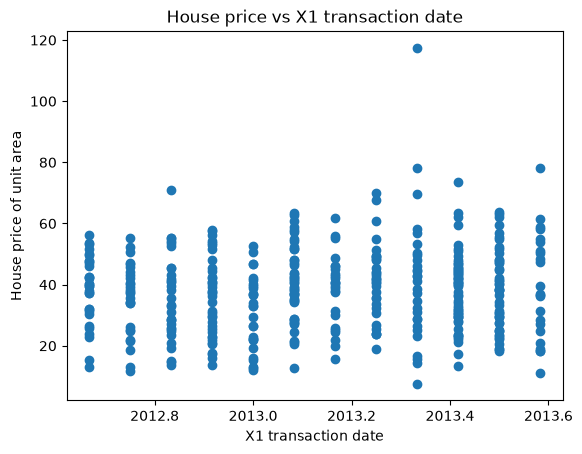

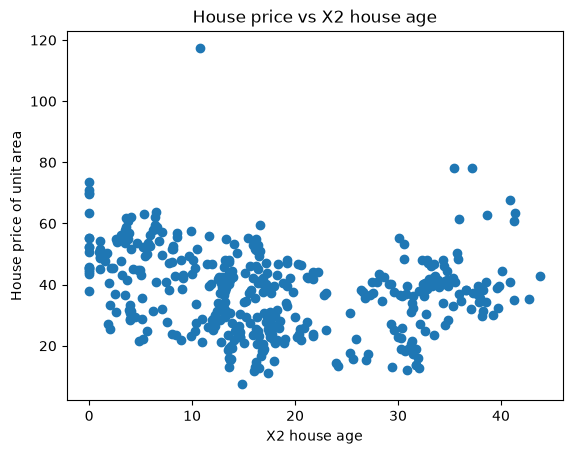

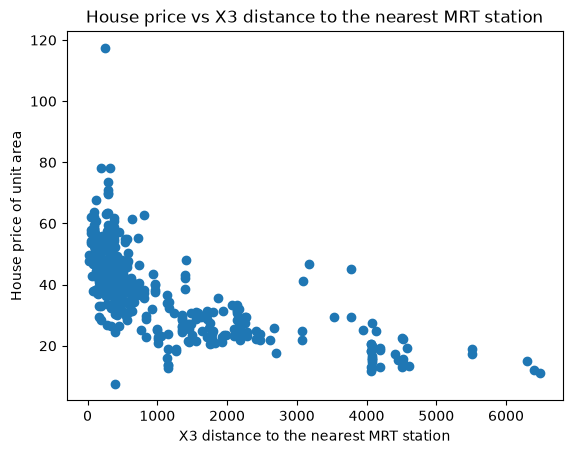

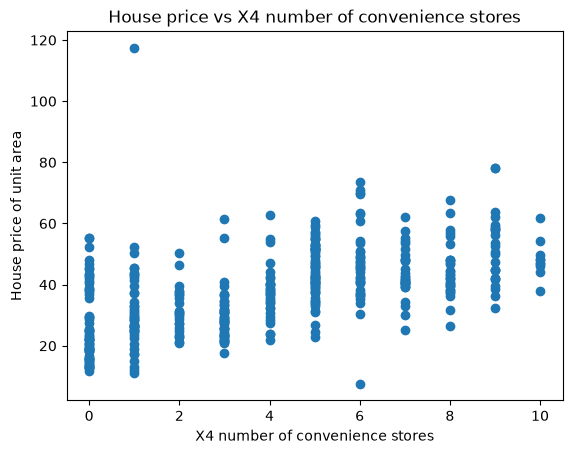

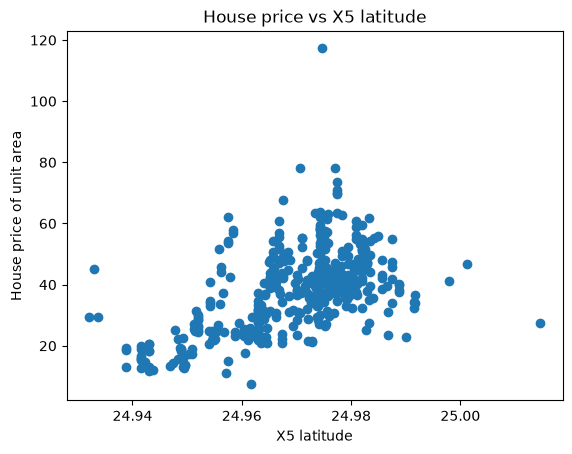

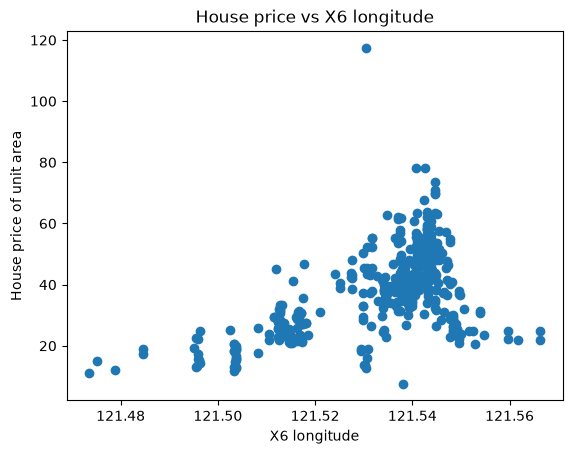

In [6]:
import matplotlib.pyplot as plt

for column in linear_X.columns:
    plt.scatter(linear_X[column], y)
    plt.title(f'House price vs {column}')
    plt.xlabel(column)
    plt.ylabel('House price of unit area')
    plt.show()

## Johtopäätökset

Eniten lineaarisesti vaikuttavia on asunnon sijainti kartalla (longitude ja lattitude), asunnon etäisyys MRT, eli Mass Rapid Transport (julkiset yhteydet), ja ruokakauppojen lukumäärä jalankulkuetäisyydellä asunnosta.

Vähiten vaikutti ostovuosi ja talon ikä.

Tarkastellaan lineaarisuutta asunnon sijaintien, etäisyyden julkisiinliikenteisiin ja ruokakauppojen määrään.

## Etäisyys julkisiinliikenteisiin

In [7]:
test_size = 0.25
random_state = 123

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

linear_X_mrt = linear_X[['X3 distance to the nearest MRT station']]
linear_y_mrt = linear_y

X_linear_train_mrt, X_linear_test_mrt, y_linear_train_mrt, y_linear_test_mrt = train_test_split(
    linear_X_mrt, linear_y_mrt,
    test_size=test_size,
    random_state=42
)

In [9]:
linear_regression_model_mrt = LinearRegression()

linear_regression_model_mrt.fit(X_linear_train_mrt, y_linear_train_mrt)

b0_mrt = linear_regression_model_mrt.intercept_
b1_mrt = linear_regression_model_mrt.coef_[0]

y_pred_mrt = linear_regression_model_mrt.predict(X_linear_test_mrt)

mae_mrt = mean_absolute_error(y_linear_test_mrt, y_pred_mrt)
r2_mrt = r2_score(y_linear_test_mrt, y_pred_mrt)

## Jalankulku etäisyydellä olevien ruokakauppojen määrä

In [10]:
linear_X_convenience = linear_X[['X4 number of convenience stores']]
linear_y_convenience = linear_y

X_linear_train_convenience, X_linear_test_convenience, y_linear_train_convenience, y_linear_test_convenience = train_test_split(
    linear_X_convenience, linear_y_convenience,
    test_size=test_size,
    random_state=random_state
)

In [11]:
linear_regression_model_convenience = LinearRegression()

linear_regression_model_convenience.fit(X_linear_train_convenience, y_linear_train_convenience)

b0_convenience = linear_regression_model_convenience.intercept_
b1_convenience = linear_regression_model_convenience.coef_[0]

y_pred_convenience= linear_regression_model_convenience.predict(X_linear_test_convenience)

mae_convenience = mean_absolute_error(y_linear_test_convenience, y_pred_convenience)
r2_convenience = r2_score(y_linear_test_convenience, y_pred_convenience)

## Sijainti leveysateena

In [12]:
linear_X_latitude = linear_X[['X5 latitude']]
linear_y_latitude = linear_y

X_linear_train_latitude, X_linear_test_latitude, y_linear_train_latitude, y_linear_test_latitude = train_test_split(
    linear_X_latitude, linear_y_latitude,
    test_size=test_size,
    random_state=random_state
)

In [13]:
linear_regression_model_latitude = LinearRegression()

linear_regression_model_latitude.fit(X_linear_train_latitude, y_linear_train_latitude)

b0_latitude = linear_regression_model_latitude.intercept_
b1_latitude = linear_regression_model_latitude.coef_[0]

y_pred_latitude = linear_regression_model_latitude.predict(X_linear_test_latitude)

mae_latitude = mean_absolute_error(y_linear_test_latitude, y_pred_latitude)
r2_latitude = r2_score(y_linear_test_latitude, y_pred_latitude)

## Sijainti pituusasteena

In [14]:
linear_X_longitude = linear_X[['X6 longitude']]
linear_y_longitude = linear_y

X_linear_train_longitude, X_linear_test_longitude, y_linear_train_longitude, y_linear_test_longitude = train_test_split(
    linear_X_longitude, linear_y_longitude,
    test_size=test_size,
    random_state=random_state
)

In [15]:
linear_regression_model_longitude = LinearRegression()

linear_regression_model_longitude.fit(X_linear_train_longitude, y_linear_train_longitude)

b0_longitude = linear_regression_model_longitude.intercept_
b1_longitude = linear_regression_model_longitude.coef_[0]

y_pred_longitude = linear_regression_model_longitude.predict(X_linear_test_longitude)

mae_longitude = mean_absolute_error(y_linear_test_longitude, y_pred_longitude)
r2_longitude = r2_score(y_linear_test_longitude, y_pred_longitude)

### Vertaillaan 4 valitun muuttujan tuloksia

In [16]:
print('MRT dataa:')
print('  - MAE: ', mae_mrt)
print('  - R²: ', r2_mrt)
print('  - Intercept: ', b0_mrt)
print('  - Koeffisienssi: ', b1_mrt)

print('')

print('Lähimmät kaupat dataa:')
print('  - MAE: ', mae_convenience)
print('  - R²: ', r2_convenience)
print('  - Intercept: ', b0_convenience)
print('  - Koeffisienssi: ', b1_convenience)

print('')

print('Leveyspiirin dataa:')
print('  - MAE: ', mae_latitude)
print('  - R²: ', r2_latitude)
print('  - Intercept: ', b0_latitude)
print('  - Koeffisienssi: ', b1_latitude)

print('')

print('Pituuspiirin dataa:')
print('  - MAE: ', mae_longitude)
print('  - R²: ', r2_longitude)
print('  - Intercept: ', b0_longitude)
print('  - Koeffisienssi: ', b1_longitude)

print('')

MRT dataa:
  - MAE:  7.300766707089707
  - R²:  0.4379807833340794
  - Intercept:  46.668460635196475
  - Koeffisienssi:  -0.007502130032896735

Lähimmät kaupat dataa:
  - MAE:  8.113287259091656
  - R²:  0.4415944019747211
  - Intercept:  27.69575574351817
  - Koeffisienssi:  2.557053078368631

Leveyspiirin dataa:
  - MAE:  7.602610018934511
  - R²:  0.40973301635212367
  - Intercept:  -14301.586195584978
  - Koeffisienssi:  574.2858276777051

Pituuspiirin dataa:
  - MAE:  8.025382131136755
  - R²:  0.33550953641400494
  - Intercept:  -54887.17698654993
  - Koeffisienssi:  451.9351519396092

